**Dave**

- MSE
- RMSE
- MAE
- Summary metrics table
- Written conclusion

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd
from sklearn.metrics import mean_absolute_error

from preprocessing import df_basic_cleaning_and_split, array_standardise_data, df_feature_constructions
from model1_baseline import train_NN, forward

In [3]:
# Preparing the data
include_added_features = False
if include_added_features:  
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3)
    X_train, X_test = df_feature_constructions(X_train, X_test)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
else:
    X_train, X_test, y_train, y_test = df_basic_cleaning_and_split(test_size=0.3, include_additional_features=False)
    X_train, X_test, y_train, y_test = array_standardise_data(X_train, X_test, y_train, y_test)
    

In [4]:
print("Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)")

W1_t, b1_t, w2_t, b2_t, losses = train_NN(X_train, y_train, hidden=64, lr=0.001, iters=10_000)

y_pred_m1, _ = forward(X_test, W1_t, b1_t, w2_t, b2_t)
m1_standard_mse = mean_squared_error(y_test, y_pred_m1)
print(f"Model 1 ran Final Test MSE: {m1_standard_mse:.4f}")

Training Model 1 for 10,000 iterations will prob take few mins(lat time it took 4 mins)
Model 1 ran Final Test MSE: 0.4594


Training Model 2 (Sklearn MLPRegressor)...
Model 2 ran Final Test MSE: 0.2979


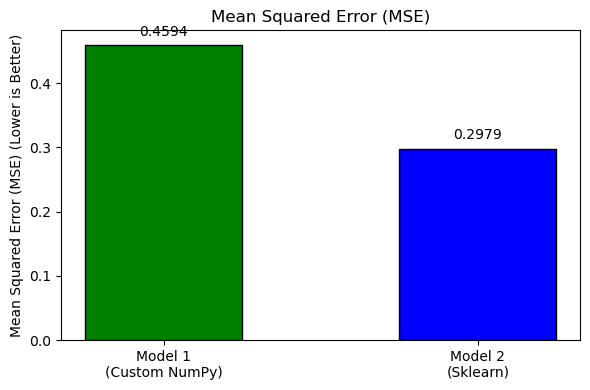

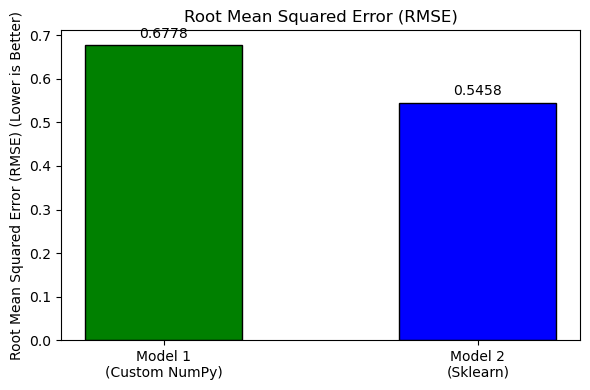

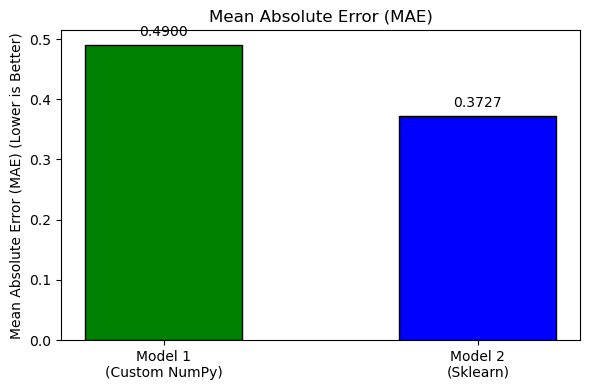

In [6]:
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training Model 2 (Sklearn MLPRegressor)...")
clf = MLPRegressor(solver='adam', alpha=1e-5, learning_rate='constant',
                   learning_rate_init=0.001, hidden_layer_sizes=(64,), 
                   random_state=1, max_iter=10000)
clf.fit(X_train, y_train)

y_pred_m2 = clf.predict(X_test)
m2_standard_mse = mean_squared_error(y_test, y_pred_m2)
print(f"Model 2 ran Final Test MSE: {m2_standard_mse:.4f}")

def plot_metric_comparison(metric_name, m1_score, m2_score):
    fig, axs = plt.subplots(1, 1, figsize=(6, 4)) 
    bars = axs.bar(['Model 1\n(Custom NumPy)', 'Model 2\n(Sklearn)'], 
                   [m1_score, m2_score], 
                   color=["green", "blue"], edgecolor='black', width=0.5)
    
    axs.set_title(f'{metric_name}', fontsize=12)
    axs.set_ylabel(f'{metric_name} (Lower is Better)')

    for bar in bars:
        axs.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{bar.get_height():.4f}', ha='center', va='bottom')
                 
    plt.tight_layout()
    plt.show()

m1_standard_rmse = np.sqrt(m1_standard_mse)
m2_standard_rmse = np.sqrt(m2_standard_mse)

m1_standard_mae = mean_absolute_error(y_test, y_pred_m1)
m2_standard_mae = mean_absolute_error(y_test, y_pred_m2)
plot_metric_comparison('Mean Squared Error (MSE)', m1_standard_mse, m2_standard_mse)
plot_metric_comparison('Root Mean Squared Error (RMSE)', m1_standard_rmse, m2_standard_rmse)
plot_metric_comparison('Mean Absolute Error (MAE)', m1_standard_mae, m2_standard_mae)

In [7]:
metric_data = {
    "Metric": [
        "MSE (Mean Squared Error)", 
        "RMSE (Root Mean Squared Error)", 
        "MAE (Mean Absolute Error)"
    ],
    "Model 1 (Numpy)": [
        m1_standard_mse, 
        m1_standard_rmse, 
        m1_standard_mae
    ],
    "Model 2 (Sklearn MLP)": [
        m2_standard_mse, 
        m2_standard_rmse, 
        m2_standard_mae
    ]
}
metrics_table = pd.DataFrame(metric_data)
metrics_table.set_index("Metric", inplace=True)
display(metrics_table)

,Model 1 (Numpy),Model 2 (Sklearn MLP)
Metric,,
MSE (Mean Squared Error),0.459366,0.297871
RMSE (Root Mean Squared Error),0.677766,0.545776
MAE (Mean Absolute Error),0.489961,0.372725


In [ ]:
#sklearn won by a large margin as you can see all the error is lower.